**APS Salary Analysis by Job Category and Inferred Gender**
This project analyzes publicly available Albuquerque Public Schools salary data to explore salary patterns by job category and inferred gender. Because APS does not report employee gender in the salary dataset, this analysis uses first names to infer likely gender. The results should be interpreted as exploratory, not definitive.

In [2]:
import pandas as pd

df = pd.read_csv("aps_salary_raw.csv.csv")
df.head()
df. columns

df.dropna(how="all")
df.head()
df.shape

df["annual_salary"] = (
    df["annual_salary"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)
df["annual_salary"] = pd.to_numeric(df["annual_salary"], errors="coerce")
df.head()
df[df["annual_salary"].isna()]

df["employee_name"] = df["employee_name"].astype(str).str.strip()
df["position_description"] = df["position_description"].astype(str).str.strip()
df = df.dropna(subset = ["employee_name", "position_description", "annual_salary"])
df.head()

def extract_first_name(full_name):
  if "," in full_name:
    after_comma = full_name.split(",", 1)[1].strip()
    first_name = after_comma.split()[0]
    return first_name
  return None

df["first_name"] = df["employee_name"].apply(extract_first_name)
df[["employee_name", "first_name"]].head()

def categorize_position(position):
  position_lower = position.lower()
  if "principal" in position_lower or "dean" in position_lower:
    return "Administrator"
  elif "teacher" in position_lower or "instructor" in position_lower:
    return "Teacher"
  elif "educational assistant" in position_lower or "educ asst" in position_lower:
    return "Educational Assistant"
  elif "secratary" in position_lower or "clerk" in position_lower or "adm asst" in position_lower or "administrative assistant" in position_lower:
    return "Secretary/Clerk"
  elif "custodian" in position_lower or "yardman" in position_lower:
    return "Custodian"
  elif "counselor" in position_lower or "therapist" in position_lower or "diagnostician" in position_lower or "psychologist" in position_lower or "behavior" in position_lower or "human services" in position_lower:
    return "Student Support"
  elif "nurse" in position_lower:
    return "Nurse"
  elif "coach" in position_lower or "athletics trainer" in position_lower:
    return "Coach"
  elif "director" in position_lower or "manager" in position_lower or "coordinator" in position_lower or "supervisor" in position_lower or "mgr" in position_lower:
    return "Office"
  elif "librarian" in position_lower or "library" in position_lower:
    return "Librarian"
  elif "police" in position_lower or "safety" in position_lower or "security" in position_lower:
    return "Security"
  elif "bus" in position_lower or "driver" in position_lower or "transportation" in position_lower:
    return "Transportation"
  elif "technician" in position_lower or "tech" in position_lower or "programmer" in position_lower or "analyst" in position_lower:
    return "Technology"
  elif "trades" in position_lower or "tradesman" in position_lower or "maintenance" in position_lower or "mechanic" in position_lower or "construction" in position_lower or "facilities" in position_lower or "carpentry" in position_lower:
    return "Maintenance"
  elif "pathologist" in position_lower:
    return "Pathologist"
  elif "payroll" in position_lower or "payable" in position_lower:
    return "Finance"
  else:
    return "Other"

df["job_category"] = df["position_description"].apply(categorize_position)
df[["position_description", "job_category"]].head(20)
df["job_category"].value_counts()


,count
job_category,
Teacher,5716
Educational Assistant,2137
Other,689
Custodian,673
Office,611
Student Support,576
Administrator,504
Transportation,348
Secretary/Clerk,186


In [3]:
df.to_csv("aps_salary_cleaned.csv", index=False)
from google.colab import files
files.download("aps_salary_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
!pip install gender-guesser
import pandas as pd
import gender_guesser.detector as gender

df = pd.read_csv("aps_salary_cleaned.csv")

detector = gender.Detector()
#print(detector.get_gender("Ishya"))
#print(detector.get_gender("Enoeka"))
#print(detector.get_gender("Taylor"))

def infer_gender(first_name):
  if pd.isna(first_name):
    return "unknown"
  guess = detector.get_gender(str(first_name))
  if guess in ["female", "mostly_female"]:
    return "likely_female"
  elif guess in ["male", "mostly_male"]:
    return "likely_male"
  else:
    return "unknown"

df["inferred_gender"] = df["first_name"].apply(infer_gender)
df[["employee_name", "first_name", "inferred_gender"]].head(20)
df["inferred_gender"].value_counts()
df[df["inferred_gender"] == "unknown"]["first_name"].value_counts().head(50)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 379.3/379.3 kB 14.8 MB/s eta 0:00:00


,count
first_name,
Ma,9
Casey,8
Aubrey,7
Rocio,6
Jo,5
Paige,5
O,4
Isela,4
Nissa,4


In [5]:
df.to_csv("aps_salary_with_inferred_gender.csv", index=False)
from google.colab import files
files.download("aps_salary_with_inferred_gender.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
df.columns
df["inferred_gender"].value_counts()
df["inferred_gender"].value_counts(normalize=True) * 100

df_gender = df[df["inferred_gender"].isin(["likely_female", "likely_male"])]
df_gender["inferred_gender"].value_counts()
df_gender.groupby("inferred_gender")["annual_salary"].mean()
df_gender.groupby("inferred_gender")["annual_salary"].median()

salary_summary = df_gender.groupby("inferred_gender")["annual_salary"].agg(
    count = "count",
    mean_salary = "mean",
    median_salary = "median",
    min_salary = "min",
    max_salary = "max"
    )
salary_summary

female_mean = df_gender[df_gender["inferred_gender"] == "likely_female"]["annual_salary"].mean()
male_mean = df_gender[df_gender["inferred_gender"] == "likely_male"]["annual_salary"].mean()
gap_dollars = male_mean - female_mean
gap_percent = (gap_dollars / male_mean) * 100
#negative $ = likely female average is higher
#positive $ = likely male average is higher
gap_dollars, gap_percent

category_summary = df_gender.groupby(["job_category", "inferred_gender"])["annual_salary"].agg(
    count = "count",
    mean_salary = "mean",
    median_salary = "median"
).reset_index()
category_summary.head(20)

mean_table = df_gender.pivot_table(
    values = "annual_salary",
    index = "job_category",
    columns = "inferred_gender",
    aggfunc = "mean"
)
count_table = df_gender.pivot_table(
    values = "annual_salary",
    index = "job_category",
    columns = "inferred_gender",
    aggfunc = "count"
)
analysis_table = mean_table.copy()
analysis_table["female_count"] = count_table["likely_female"]
analysis_table["male_count"] = count_table["likely_male"]
analysis_table["gap_male_minus_female"] = (
    analysis_table["likely_male"] - analysis_table["likely_female"]
)
analysis_table["gap_percent"] = (
    analysis_table["gap_male_minus_female"] / analysis_table["likely_male"]
) * 100
analysis_table

analysis_table_filtered = analysis_table[
    (analysis_table["female_count"] >= 20) &
    (analysis_table["male_count"] >= 20)
]
analysis_table_filtered

#where male salary is higher
analysis_table_filtered.sort_values("gap_male_minus_female", ascending=False)
#where female salary is higher
analysis_table_filtered.sort_values("gap_male_minus_female", ascending=True)



inferred_gender,likely_female,likely_male,female_count,male_count,gap_male_minus_female,gap_percent
job_category,,,,,,
Student Support,83009.368656,81630.694578,454.0,83.0,-1378.674078,-1.688916
Transportation,34999.585063,33917.499341,158.0,167.0,-1082.085722,-3.190346
Teacher,75566.183082,74756.124561,3709.0,1515.0,-810.058521,-1.083602
Educational Assistant,28461.731856,28612.401813,1552.0,342.0,150.669957,0.526590
Technology,55958.474828,57483.436341,87.0,82.0,1524.961514,2.652871
Custodian,35717.646652,38265.470431,227.0,394.0,2547.823779,6.658284
Other,58734.857539,61690.991739,451.0,184.0,2956.134200,4.791841
Security,59759.335200,64174.107541,25.0,61.0,4414.772341,6.879367
Secretary/Clerk,32554.891923,44185.672727,130.0,33.0,11630.780804,26.322516


In [7]:
distribution = df_gender.groupby(["job_category", "inferred_gender"]).size().reset_index(name = "count")
distribution.head(20)

distribution_table = df_gender.pivot_table(
    index = "job_category",
    columns = "inferred_gender",
    values = "employee_name",
    aggfunc = "count"
)
distribution_table

distribution_table["total"] = distribution_table["likely_female"] + distribution_table["likely_male"]
distribution_table["percent_female"] = (
    distribution_table["likely_female"] / distribution_table["total"]
) * 100
distribution_table["percent_male"] = (
    distribution_table["likely_male"] / distribution_table["total"]
) * 100

distribution_table.sort_values("total", ascending=False)


inferred_gender,likely_female,likely_male,total,percent_female,percent_male
job_category,,,,,
Teacher,3709.0,1515.0,5224.0,70.999234,29.000766
Educational Assistant,1552.0,342.0,1894.0,81.942978,18.057022
Other,451.0,184.0,635.0,71.023622,28.976378
Custodian,227.0,394.0,621.0,36.553945,63.446055
Office,392.0,163.0,555.0,70.630631,29.369369
Student Support,454.0,83.0,537.0,84.543762,15.456238
Administrator,353.0,109.0,462.0,76.406926,23.593074
Transportation,158.0,167.0,325.0,48.615385,51.384615
Technology,87.0,82.0,169.0,51.479290,48.520710


In [8]:
salary_summary.to_csv("overall_gender_salary_summary.csv")
analysis_table_filtered.to_csv("salary_gap_by_job_category.csv")

from google.colab import files
files.download("overall_gender_salary_summary.csv")
files.download("salary_gap_by_job_category.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

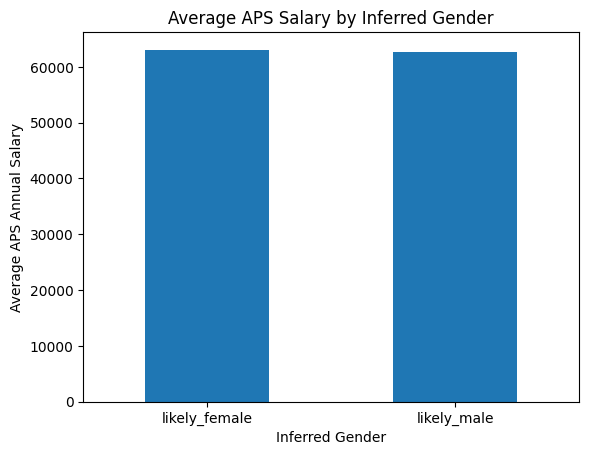

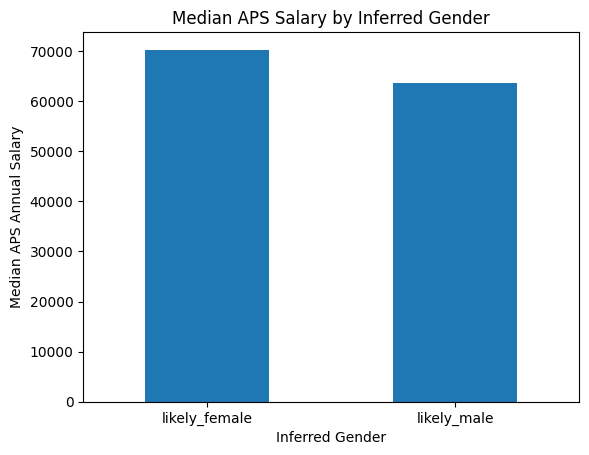

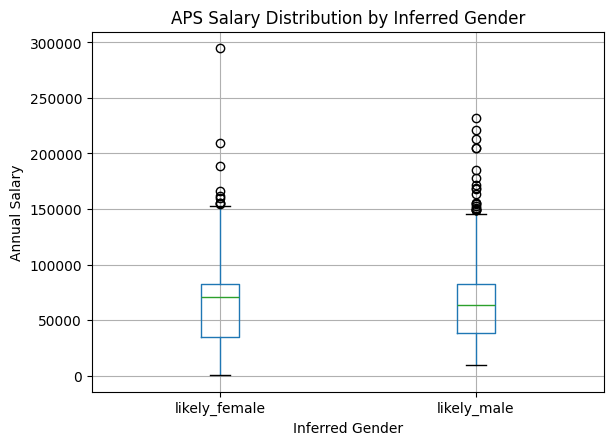

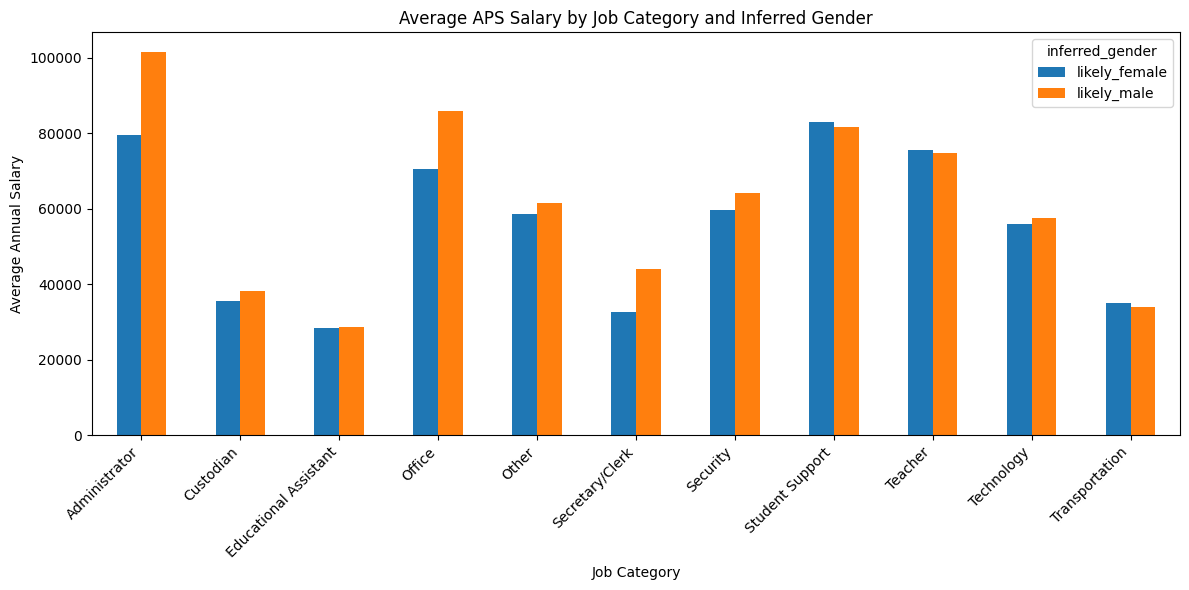

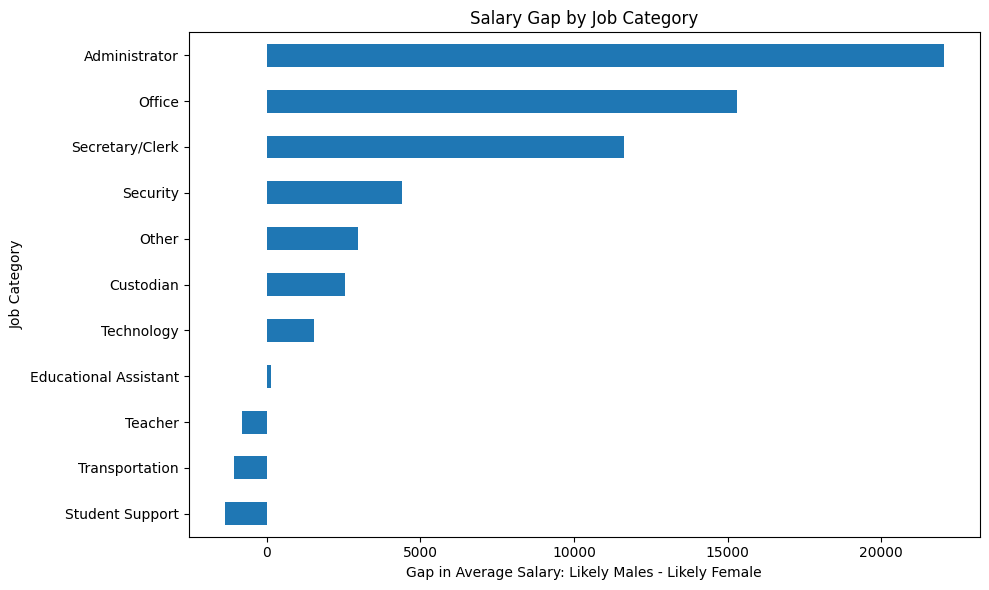

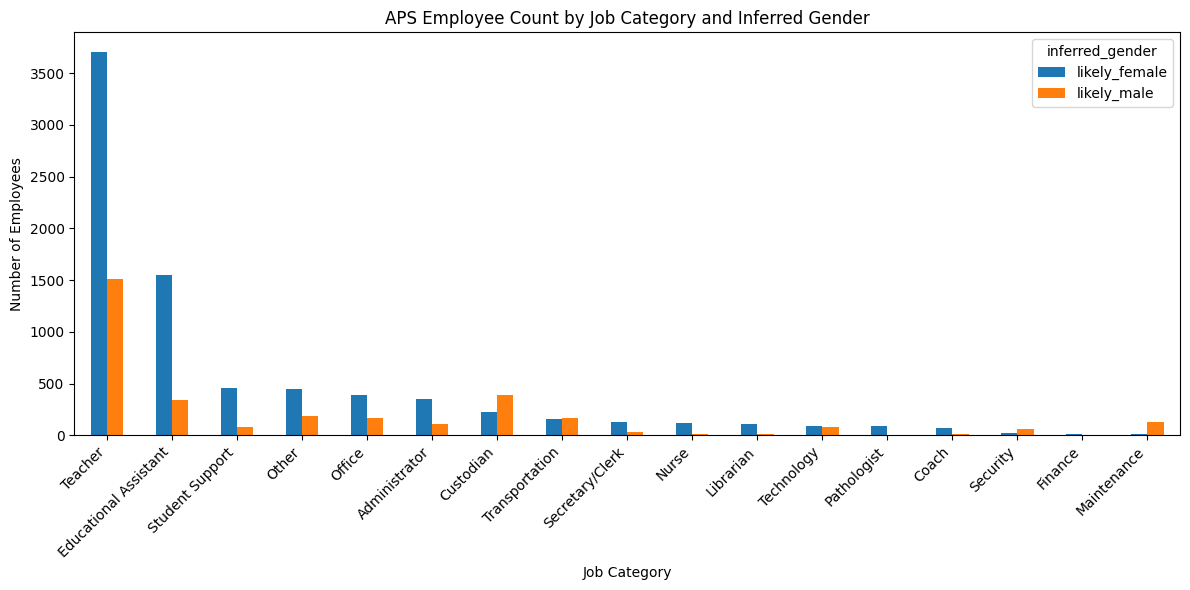

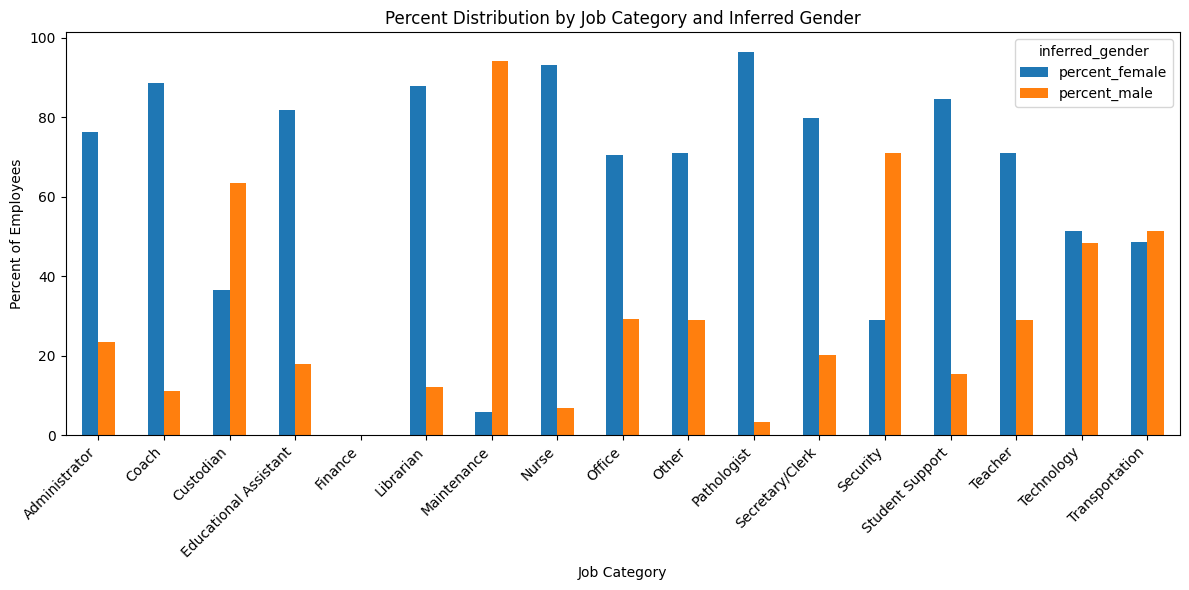

In [9]:
import matplotlib.pyplot as plt

# average salary by gender
overall_mean_salary = df_gender.groupby("inferred_gender")["annual_salary"].mean()
overall_mean_salary.plot(kind = "bar")
plt.title("Average APS Salary by Inferred Gender")
plt.xlabel("Inferred Gender")
plt.ylabel("Average APS Annual Salary")
plt.xticks(rotation = 0)
plt.savefig("mean_salary_by_inferred_gender.png", bbox_inches="tight")
plt.show()

# median salary by gender
overall_median_salary = df_gender.groupby("inferred_gender")["annual_salary"].median()
overall_median_salary.plot(kind = "bar")
plt.title("Median APS Salary by Inferred Gender")
plt.xlabel("Inferred Gender")
plt.ylabel("Median APS Annual Salary")
plt.xticks(rotation = 0)
plt.savefig("median_salary_by_inferred_gender.png", bbox_inches="tight")
plt.show()

# salary boxplot
df_gender.boxplot(
  column = "annual_salary",
  by = "inferred_gender"
)
plt.title("APS Salary Distribution by Inferred Gender")
plt.suptitle("")
plt.xlabel("Inferred Gender")
plt.ylabel("Annual Salary")
plt.savefig("salary_distribution_by_inferred_gender.png", bbox_inches="tight")
plt.show()

#average salary by job category and gender
#analysis_table_filtered
salary_by_category = analysis_table_filtered[["likely_female", "likely_male"]]
salary_by_category.plot(kind="bar", figsize=(12, 6))
plt.title("Average APS Salary by Job Category and Inferred Gender")
plt.xlabel("Job Category")
plt.ylabel("Average Annual Salary")
plt.xticks(rotation=45, ha="right")
plt.savefig("mean_salary_by_job_category.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

#salary gap by job category
gap_by_category = analysis_table_filtered["gap_male_minus_female"].sort_values()
gap_by_category.plot(kind = "barh", figsize = (10,6))
plt.title("Salary Gap by Job Category")
plt.xlabel("Gap in Average Salary: Likely Males - Likely Female")
plt.ylabel ("Job Category")
plt.savefig("salary_gap_by_job_category.png", bbox_inches="tight")
plt.tight_layout()
plt.show()
#negative = likely females make more on average
#positive = likely males make more on average

#gender distribution by job category
representation_table = df_gender.pivot_table(
    index="job_category",
    columns="inferred_gender",
    values="employee_name",
    aggfunc="count"
)
representation_table = representation_table.sort_values(
    by="likely_female",
    ascending=False
)
representation_table.plot(kind="bar", figsize=(12, 6))

plt.title("APS Employee Count by Job Category and Inferred Gender")
plt.xlabel("Job Category")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45, ha="right")
plt.savefig("gender_distribution_by_job_category.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

#percent distribution by job
distribution_percent = distribution_table.copy()
distribution_percent["total"] = (
    distribution_percent["likely_female"] + distribution_percent["likely_male"]
)
distribution_percent["percent_female"] = (
    distribution_percent["likely_female"] / distribution_percent["total"]
)*100
distribution_percent["percent_male"] = (
    distribution_percent["likely_male"] / distribution_percent["total"]
)*100
distribution_percent[["percent_female", "percent_male"]].plot(
    kind = "bar",
    figsize = (12, 6)
)
plt.title("Percent Distribution by Job Category and Inferred Gender")
plt.xlabel("Job Category")
plt.ylabel("Percent of Employees")
plt.xticks(rotation = 45, ha = "right")
plt.savefig("percent_gender_distribution_by_job_category.png", bbox_inches="tight")
plt.tight_layout()
plt.show()


In [10]:
from google.colab import files
files.download("mean_salary_by_inferred_gender.png")
files.download("median_salary_by_inferred_gender.png")
files.download("salary_distribution_by_inferred_gender.png")
files.download("mean_salary_by_job_category.png")
files.download("salary_gap_by_job_category.png")
files.download("gender_distribution_by_job_category.png")
files.download("percent_gender_distribution_by_job_category.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
display(salary_summary)
print("Overall, likely male employees had an average salary of $62735.831816, while likely female employees had an average salary of $63082.027014.")
print("Overall, likely female employees had a higher average salary than likely male employees by about $346.195198.")
print("The median salaries were $70359.06 for likely female employees and $63754.34 for likely male employees, suggesting that the typical employee salary difference was larger than the average difference.")


,count,mean_salary,median_salary,min_salary,max_salary
inferred_gender,,,,,
likely_female,7944,63082.027014,70359.06,360.00,295014.40
likely_male,3298,62735.831816,63754.34,9397.29,231635.76


Overall, likely male employees had an average salary of $62735.831816, while likely female employees had an average salary of $63082.027014.
Overall, likely female employees had a higher average salary than likely male employees by about $346.195198.
The median salaries were $70359.06 for likely female employees and $63754.34 for likely male employees, suggesting that the typical employee salary difference was larger than the average difference.


In [19]:
display(analysis_table_filtered.sort_values("gap_male_minus_female", ascending=False))
print("The largest positive salary gaps appeared in Administrator, Office, and Secretary/Clerk roles, where likely male average salaries were higher than likely female average salaries. The largest negative gaps appeared in Student Support, Transportation, and Teacher roles, where likely female average salaries were slightly higher. This suggests that salary differences vary substantially by job category rather than moving in one consistent direction across APS.")

inferred_gender,likely_female,likely_male,female_count,male_count,gap_male_minus_female,gap_percent
job_category,,,,,,
Administrator,79665.241161,101712.419266,353.0,109.0,22047.178105,21.675994
Office,70700.207781,86015.510184,392.0,163.0,15315.302403,17.805280
Secretary/Clerk,32554.891923,44185.672727,130.0,33.0,11630.780804,26.322516
Security,59759.335200,64174.107541,25.0,61.0,4414.772341,6.879367
Other,58734.857539,61690.991739,451.0,184.0,2956.134200,4.791841
Custodian,35717.646652,38265.470431,227.0,394.0,2547.823779,6.658284
Technology,55958.474828,57483.436341,87.0,82.0,1524.961514,2.652871
Educational Assistant,28461.731856,28612.401813,1552.0,342.0,150.669957,0.526590
Teacher,75566.183082,74756.124561,3709.0,1515.0,-810.058521,-1.083602


The largest positive salary gaps appeared in Administrator, Office, and Secretary/Clerk roles, where likely male average salaries were higher than likely female average salaries. The largest negative gaps appeared in Student Support, Transportation, and Teacher roles, where likely female average salaries were slightly higher. This suggests that salary differences vary substantially by job category rather than moving in one consistent direction across APS.


In [20]:
display(distribution_table.sort_values("total", ascending = False))
print("The representation table shows that APS job categories are not evenly distributed by inferred gender. Teacher, Educational Assistant, Office, Student Support, Administrator, Nurse, Librarian, Pathologist, and Coach roles were majority likely female, while Custodian, Maintenance, Transportation, and Security roles had higher likely male representation. This matters because overall salary differences may reflect which groups are concentrated in higher or lower paying job categories, not only pay differences within the same job type.")

inferred_gender,likely_female,likely_male,total,percent_female,percent_male
job_category,,,,,
Teacher,3709.0,1515.0,5224.0,70.999234,29.000766
Educational Assistant,1552.0,342.0,1894.0,81.942978,18.057022
Other,451.0,184.0,635.0,71.023622,28.976378
Custodian,227.0,394.0,621.0,36.553945,63.446055
Office,392.0,163.0,555.0,70.630631,29.369369
Student Support,454.0,83.0,537.0,84.543762,15.456238
Administrator,353.0,109.0,462.0,76.406926,23.593074
Transportation,158.0,167.0,325.0,48.615385,51.384615
Technology,87.0,82.0,169.0,51.479290,48.520710


The representation table shows that APS job categories are not evenly distributed by inferred gender. Teacher, Educational Assistant, Office, Student Support, Administrator, Nurse, Librarian, Pathologist, and Coach roles were majority likely female, while Custodian, Maintenance, Transportation, and Security roles had higher likely male representation. This matters because overall salary differences may reflect which groups are concentrated in higher or lower paying job categories, not only pay differences within the same job type.


In [22]:
#findings summary
findings = pd.DataFrame({
    "Question": [
        "Overall average salary difference",
        "Overall median salary difference",
        "Largest male-higher category gaps",
        "Largest female-higher category gaps",
        "Role distribution pattern",
        "Main limitation"
    ],
    "Finding": [
        "Likely female employees had a slightly higher average salary than likely male employees: $63,082.03 vs. $62,735.83, a difference of about $346.20.",
        "Likely female employees had a higher median salary than likely male employees: $70,359.06 vs. $63,754.34.",
        "The largest male-higher average salary gaps appeared in Administrator, Office, and Secretary/Clerk roles.",
        "The largest female-higher average salary gaps appeared in Student Support, Transportation, and Teacher roles.",
        "Likely female employees made up a large majority of Teachers, Educational Assistants, Student Support, Nurses, Librarians, Pathologists, and Secretary/Clerk roles. Likely male employees were more represented in Custodian, Maintenance, Security, and Transportation roles.",
        "Gender was inferred from first names, not reported by APS, so the results are exploratory and may include misclassification."
    ]
})
findings

,Question,Finding
0,Overall average salary difference,Likely female employees had a slightly higher ...
1,Overall median salary difference,Likely female employees had a higher median sa...
2,Largest male-higher category gaps,The largest male-higher average salary gaps ap...
3,Largest female-higher category gaps,The largest female-higher average salary gaps ...
4,Role distribution pattern,Likely female employees made up a large majori...
5,Main limitation,"Gender was inferred from first names, not repo..."


In [24]:
df.to_csv("aps_salary_final_dataset.csv", index=False)
from google.colab import files
files.download("aps_salary_final_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>